# Notebook 8: Generative Models — VAE and DDPM Diffusion
**UCU Deep Learning Course**

In Notebook 7 we built a decoder-only transformer that **generates text** by sampling one token at a time from a learned distribution over the next character. That was already a generative model — but a *sequential, autoregressive* one. In this notebook we step into two very different ways of modelling a data distribution, both for **images**:

1. **Variational Autoencoders (VAEs)** — encode an image to a low-dimensional Gaussian latent, decode back, and train with the **ELBO** (reconstruction + KL).
2. **Denoising Diffusion Probabilistic Models (DDPM)** — corrupt an image with Gaussian noise over $T$ steps, then train a U-Net to undo the corruption one step at a time.

Both will be built **from scratch** in plain PyTorch on **MNIST** (28×28 digits). At the end of the lab you should be able to look at samples from both models side-by-side and *see* the trade-off the lecture talked about — VAE samples are blurry but the model gives you a meaningful latent code; DDPM samples are sharp but cost $T$ forward passes to generate.

### What you'll learn

1. Implement a **Gaussian VAE** — encoder, **reparameterization trick**, Bernoulli decoder, and the **ELBO** loss (BCE reconstruction + closed-form KL).
2. **Sample** from the VAE prior and **interpolate** between two real images in latent space.
3. Implement DDPM's **forward noising process** using the closed-form marginal $q(z_t\mid x)$.
4. Build a small **U-Net** with sinusoidal time embedding and train it with the noise-prediction MSE objective.
5. Implement the **DDPM reverse sampling loop** and visualize the denoising trajectory.
6. Compare VAE and DDPM samples on the same dataset — connecting back to lecture §6's trade-off table.
7. *(Optional)* Run a pretrained DDPM from HuggingFace **`diffusers`**, swap the scheduler from DDPM to DDIM, and see the ~20× speedup at similar quality.

### References

| Topic | Link |
|-------|------|
| Lecture 9 notes | `../../lectures/lecture 9/notes.md` |
| *Auto-Encoding Variational Bayes* (Kingma & Welling, 2013) | https://arxiv.org/abs/1312.6114 |
| *Denoising Diffusion Probabilistic Models* (Ho et al., 2020) | https://arxiv.org/abs/2006.11239 |
| HuggingFace `diffusers` | https://huggingface.co/docs/diffusers/index |
| `torch.distributions` | https://docs.pytorch.org/docs/stable/distributions.html |
| `torchvision.utils.make_grid` | https://docs.pytorch.org/vision/stable/generated/torchvision.utils.make_grid.html |

> **Heads-up.** The VAE is light and trains fine on CPU. The DDPM has a small U-Net but still needs ~10–15 minutes on **MPS / CUDA**; on CPU it will be substantially slower — reduce `epochs` or `T` if you are CPU-only.


---

## Part 0 — Setup

Imports, seeds, and device selection. We follow the same `cuda → mps → cpu` pattern as Notebooks 6–7.


In [ ]:
import importlib, subprocess, sys
for pkg in ['torchinfo', 'tqdm']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])


In [ ]:
from __future__ import annotations

import math
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torchinfo import summary

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

# UCU color palette
C1, C2, C3 = "#19326E", "#50ACB0", "#CD742A"
C4, C5, C6, C7 = "#A3477F", "#907FAB", "#4294CC", "#89A943"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    print("WARNING: training the DDPM U-Net on CPU is slow.")
    print("         Consider lowering ddpm_epochs or T below if you are on CPU.")

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: mps
PyTorch version: 2.12.0


---

## Part 1 — Data: MNIST (~5 min)

We use **MNIST**: 60k train + 10k test 28×28 grayscale handwritten digits. This is the *first* time MNIST appears in this series — its sibling FashionMNIST has been the running benchmark through Notebooks 0–4. Digits are visually unambiguous in a way that fashion items are not, which makes the difference between blurry VAE samples and sharp DDPM samples obvious to the eye.

We deliberately do **not** standardise to mean/std: the Bernoulli VAE decoder in Part 2 wants pixels in $[0, 1]$, and the DDPM in Part 3 will apply its own rescaling to $[-1, 1]$ inside its training loop.


In [ ]:
transform = transforms.ToTensor()  # pixels in [0, 1]
data_root = "./data"

train_set = datasets.MNIST(data_root, train=True, download=True, transform=transform)
test_set = datasets.MNIST(data_root, train=False, download=True, transform=transform)

batch_size: int = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f"Train set: {len(train_set):,} images")
print(f"Test set : {len(test_set):,} images")
print(f"Image shape: {train_set[0][0].shape}, pixel range: [{train_set[0][0].min():.2f}, {train_set[0][0].max():.2f}]")


Train set: 60,000 images
Test set : 10,000 images
Image shape: torch.Size([1, 28, 28]), pixel range: [0.00, 1.00]


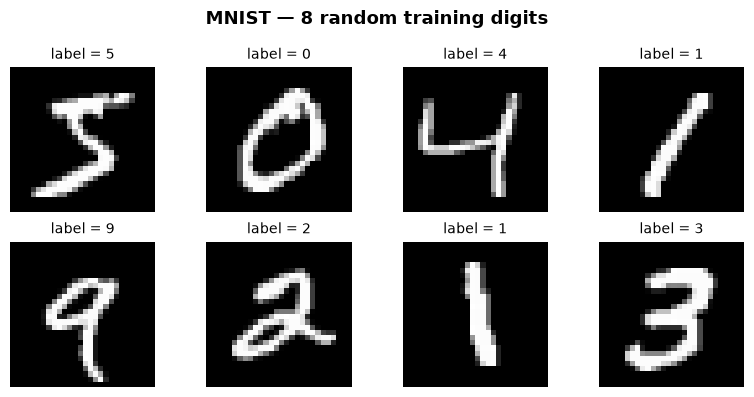

In [ ]:
# Provided visualization: a few training digits
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, (img, label) in zip(axes.flat, [train_set[i] for i in range(8)]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"label = {label}", fontsize=10)
    ax.axis("off")
plt.suptitle("MNIST — 8 random training digits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Part 2 — Variational Autoencoder (~35 min)

Lecture §2 derived the VAE objective by writing the log-likelihood as

$$
\log p_{\boldsymbol\phi}(\mathbf{x}) \;=\; \underbrace{\mathbb{E}_{q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})}\!\bigl[\log p_{\boldsymbol\phi}(\mathbf{x}\mid\mathbf{z})\bigr]}_{\text{reconstruction}}
\;-\; \underbrace{D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,p(\mathbf{z})\bigr]}_{\text{KL regularizer}}
\;+\; D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,p_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})\bigr].
$$

The last term is the gap between our **variational posterior** $q$ and the true (intractable) posterior. It is always $\ge 0$, so the first two terms form a **lower bound** on the log-likelihood — the **ELBO**. We maximise the ELBO; equivalently, we minimise its negative:

$$
\mathcal{L} \;=\; \underbrace{-\mathbb{E}_q\!\bigl[\log p_{\boldsymbol\phi}(\mathbf{x}\mid\mathbf{z})\bigr]}_{\text{recon loss}} \;+\; \underbrace{D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,\mathcal{N}(0,\mathbf{I})\bigr]}_{\text{closed-form KL}}.
$$

Two technical facts we will use:

- For a Bernoulli decoder over pixels in $[0, 1]$, the negative log-likelihood is **binary cross-entropy**. We work with logits and use `F.binary_cross_entropy_with_logits` for numerical stability (same lesson as `CrossEntropyLoss` on logits in Notebooks 4–7).
- For a diagonal-Gaussian encoder $q(\mathbf{z}\mid\mathbf{x}) = \mathcal{N}(\boldsymbol\mu, \mathrm{diag}(\boldsymbol\sigma^2))$ against a standard-normal prior, the KL has a **closed form**:

  $$
  D_{\mathrm{KL}}\!\bigl[\mathcal{N}(\boldsymbol\mu, \boldsymbol\sigma^2)\,\Vert\,\mathcal{N}(0, \mathbf{I})\bigr]
  \;=\; -\tfrac{1}{2}\sum_d \bigl(1 + \log\sigma_d^2 - \mu_d^2 - \sigma_d^2\bigr).
  $$

We parameterise the encoder to output `log(sigma^2)` (`logvar`) rather than `sigma` directly — this keeps the variance positive without a constraint and makes the KL formula above plug in cleanly.


### Exercise 2.1 — The VAE class

Implement the `VAE` class:

- `encoder = nn.Sequential(Linear(784, 400), ReLU())`
- `fc_mu = nn.Linear(400, z_dim)` and `fc_logvar = nn.Linear(400, z_dim)` — two separate heads
- `decoder = nn.Sequential(Linear(z_dim, 400), ReLU(), Linear(400, 784))` — returns **logits**, *not* probabilities
- `reparameterize(mu, logvar)`: compute `std = (0.5 * logvar).exp()`, draw `eps ~ N(0, I)` with `torch.randn_like(std)`, return `mu + std * eps`
- `forward(x)`: flatten the image, encode, reparameterize, decode; return `(logits, mu, logvar)`

Use `z_dim=16` as the default.


In [ ]:
class VAE(nn.Module):
    def __init__(self, x_dim: int = 784, h_dim: int = 400, z_dim: int = 16):
        super().__init__()
        self.x_dim = x_dim
        self.z_dim = z_dim
        self.encoder = nn.Sequential(
            nn.Linear(x_dim, h_dim),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(h_dim, z_dim)
        self.fc_logvar = nn.Linear(h_dim, z_dim)
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, x_dim)
        )
    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
      h = self.encoder(x)
      mu = self.fc_mu(h)
      logvar = self.fc_logvar(h)
      return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
      x_flat = x.view(-1, self.x_dim)
      mu, logvar = self.encode(x_flat)
      z = self.reparameterize(mu, logvar)
      logits = self.decode(z)
      return logits, mu, logvar

In [ ]:
# Sanity check on shapes
vae = VAE().to(device)
x_sample, _ = next(iter(train_loader))
x_sample = x_sample.to(device)
logits, mu, logvar = vae(x_sample)
print(f"logits: {tuple(logits.shape)}")
print(f"mu    : {tuple(mu.shape)}")
print(f"logvar: {tuple(logvar.shape)}")
summary(vae, input_size=(1, 1, 28, 28), depth=2)


logits: (256, 784)
mu    : (256, 16)
logvar: (256, 16)


Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 784]                  --
├─Sequential: 1-1                        [1, 400]                  --
│    └─Linear: 2-1                       [1, 400]                  314,000
│    └─ReLU: 2-2                         [1, 400]                  --
├─Linear: 1-2                            [1, 16]                   6,416
├─Linear: 1-3                            [1, 16]                   6,416
├─Sequential: 1-4                        [1, 784]                  --
│    └─Linear: 2-3                       [1, 400]                  6,800
│    └─ReLU: 2-4                         [1, 400]                  --
│    └─Linear: 2-5                       [1, 784]                  314,384
Total params: 648,016
Trainable params: 648,016
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.65
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.59
Estimated T

### Exercise 2.2 — The ELBO loss

Implement `elbo_loss(logits, x, mu, logvar, beta=1.0)`:

- **Reconstruction loss**: `F.binary_cross_entropy_with_logits(logits, x.view(B, -1), reduction='sum')`. Using `reduction='sum'` (over batch *and* pixels) and then dividing the final total by the batch size gives a per-image loss whose magnitude is comparable to the KL — a common pattern.
- **KL term**: closed-form, `kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum()`
- Return `(total, recon, kl)`, all averaged over batch (i.e. divide each by `B`).
- The `beta` argument scales the KL term — leave it at `1.0` for the vanilla VAE. (We will play with `beta` in the optional extension.)


In [ ]:
def elbo_loss(
    logits: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
  B = x.size(0)
  recon_sum = F.binary_cross_entropy_with_logits(logits, x.view(B, -1), reduction='sum')
  recon = recon_sum / B
  kl_sum = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  kl = kl_sum / B
  total = recon + beta * kl

  return total, recon, kl

> **Question 2.1** — Why do we use `binary_cross_entropy_with_logits` instead of computing `sigmoid` followed by `binary_cross_entropy`? Mathematically the two are identical.

`binary_cross_entropy_with_logits` aplica el sigmoide y el logaritmo de forma fusionada usando el truco log-sum-exp, evitando calcular explícitamente exponenciales y logaritmos que pueden desbordar o producir `log(0) = -inf`. Hacer `sigmoid` seguido de `binary_cross_entropy` por separado es numéricamente inestable cuando los logits son muy grandes o muy negativos.


> **Question 2.2** — Suppose you set the KL coefficient to 0 (i.e. drop the regularizer entirely). What does the model degenerate into, and what would the unconditional samples look like?

Sin el término KL el modelo degenera en un autoencoder determinista común, ya que el espacio latente deja de estar regularizado hacia $\mathcal{N}(0,I)$ y queda lleno de "huecos" sin estructura. Al muestrear del prior $z \sim \mathcal{N}(0,I)$ caerías en zonas no entrenadas del latente, produciendo imágenes incoherentes o basura en lugar de dígitos.


### Exercise 2.3 — Train the VAE

Reusable training helpers are provided below. Your job: pick the hyperparameters (suggested: `epochs=15`, `lr=1e-3`, Adam), run training, and record `(total, recon, kl)` for both train and test sets per epoch.


In [ ]:
def train_vae_epoch(
    model: VAE,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    beta: float = 1.0,
) -> tuple[float, float, float]:
    model.train()
    total_sum = recon_sum = kl_sum = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(x)
        total, recon, kl = elbo_loss(logits, x, mu, logvar, beta=beta)
        total.backward()
        optimizer.step()
        bs = x.size(0)
        total_sum += total.item() * bs
        recon_sum += recon.item() * bs
        kl_sum += kl.item() * bs
        n += bs
    return total_sum / n, recon_sum / n, kl_sum / n


@torch.no_grad()
def evaluate_vae(
    model: VAE,
    loader: DataLoader,
    device: torch.device,
    beta: float = 1.0,
) -> tuple[float, float, float]:
    model.eval()
    total_sum = recon_sum = kl_sum = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        logits, mu, logvar = model(x)
        total, recon, kl = elbo_loss(logits, x, mu, logvar, beta=beta)
        bs = x.size(0)
        total_sum += total.item() * bs
        recon_sum += recon.item() * bs
        kl_sum += kl.item() * bs
        n += bs
    return total_sum / n, recon_sum / n, kl_sum / n


In [ ]:
import torch
import torch.optim as optim

device = torch.device("mps") if torch.backends.mps.is_available() else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
vae_epochs = 15
lr = 1e-3
beta = 1.0
model = VAE(x_dim=784, h_dim=400, z_dim=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
history = {
    "train_total": [], "train_recon": [], "train_kl": [],
    "test_total": [],  "test_recon": [],  "test_kl": []
}
for epoch in range(vae_epochs):
    train_total, train_recon, train_kl = train_vae_epoch(
        model, train_loader, optimizer, device, beta=beta
    )
    test_total, test_recon, test_kl = evaluate_vae(
        model, test_loader, device, beta=beta
    )
    history["train_total"].append(train_total)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)
    history["test_total"].append(test_total)
    history["test_recon"].append(test_recon)
    history["test_kl"].append(test_kl)

    print(f"Epoch {epoch+1:02d}/{vae_epochs:02d} | "
          f"Train Loss: {train_total:.2f} (Recon: {train_recon:.2f}, KL: {train_kl:.2f}) | "
          f"Test Loss: {test_total:.2f} (Recon: {test_recon:.2f}, KL: {test_kl:.2f})")

vae = model

Epoch 01/15 | Train Loss: 190.83 (Recon: 178.72, KL: 12.11) | Test Loss: 143.11 (Recon: 125.62, KL: 17.49)
Epoch 02/15 | Train Loss: 132.36 (Recon: 113.30, KL: 19.06) | Test Loss: 123.81 (Recon: 103.25, KL: 20.56)
Epoch 03/15 | Train Loss: 121.24 (Recon: 100.24, KL: 21.00) | Test Loss: 117.38 (Recon: 95.84, KL: 21.54)
Epoch 04/15 | Train Loss: 116.83 (Recon: 95.19, KL: 21.65) | Test Loss: 114.25 (Recon: 91.92, KL: 22.33)
Epoch 05/15 | Train Loss: 114.27 (Recon: 92.23, KL: 22.04) | Test Loss: 112.28 (Recon: 90.36, KL: 21.92)
Epoch 06/15 | Train Loss: 112.51 (Recon: 90.24, KL: 22.26) | Test Loss: 110.97 (Recon: 88.63, KL: 22.34)
Epoch 07/15 | Train Loss: 111.25 (Recon: 88.75, KL: 22.50) | Test Loss: 109.76 (Recon: 87.08, KL: 22.67)
Epoch 08/15 | Train Loss: 110.23 (Recon: 87.62, KL: 22.61) | Test Loss: 109.14 (Recon: 86.66, KL: 22.47)
Epoch 09/15 | Train Loss: 109.43 (Recon: 86.68, KL: 22.75) | Test Loss: 108.60 (Recon: 85.58, KL: 23.01)
Epoch 10/15 | Train Loss: 108.81 (Recon: 85.94, KL

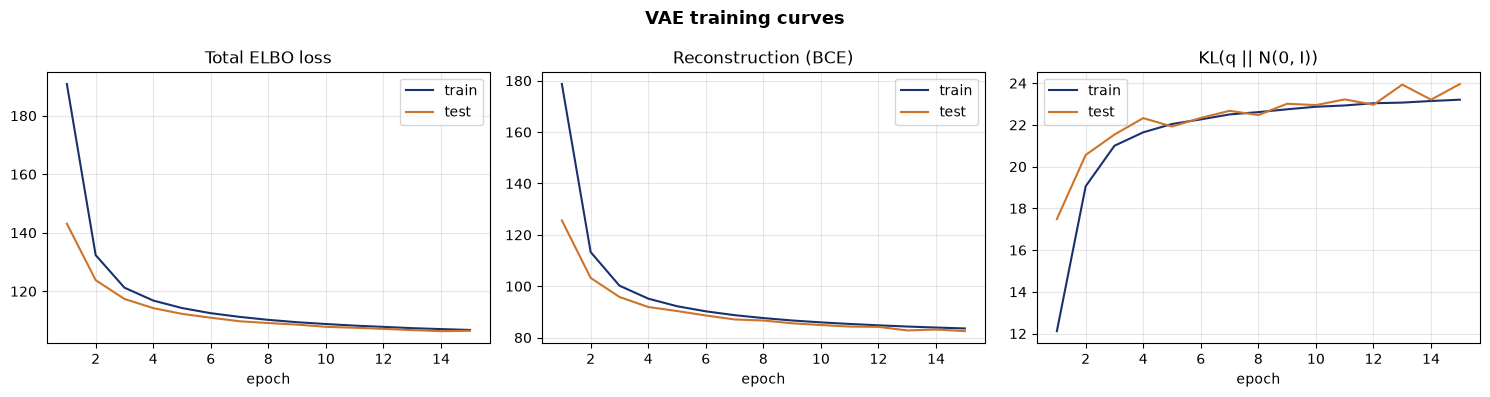

In [ ]:
# Provided plot: total / recon / KL vs epoch
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_axis = range(1, vae_epochs + 1)

axes[0].plot(epochs_axis, history["train_total"], label="train", color=C1)
axes[0].plot(epochs_axis, history["test_total"], label="test", color=C3)
axes[0].set_title("Total ELBO loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_axis, history["train_recon"], label="train", color=C1)
axes[1].plot(epochs_axis, history["test_recon"], label="test", color=C3)
axes[1].set_title("Reconstruction (BCE)"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_axis, history["train_kl"], label="train", color=C1)
axes[2].plot(epochs_axis, history["test_kl"], label="test", color=C3)
axes[2].set_title("KL(q || N(0, I))"); axes[2].set_xlabel("epoch"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("VAE training curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Exercise 2.4 — Sample from the prior

Implement `vae_sample(model, n_samples=16, z_dim=16)`:

1. Draw `z ~ N(0, I)` of shape `(n_samples, z_dim)` on the right device.
2. Decode to logits.
3. Apply `sigmoid` to get probabilities (= image pixel intensities).
4. Reshape to `(n_samples, 1, 28, 28)` and return as a CPU tensor.

Wrap the body in `@torch.no_grad()`.


In [ ]:
@torch.no_grad()
def vae_sample(model: VAE, n_samples: int = 16, z_dim: int = 16) -> torch.Tensor:
    device = next(model.parameters()).device
    z = torch.randn(n_samples, z_dim, device=device)
    logits = model.decode(z)
    probs = torch.sigmoid(logits)
    images = probs.view(n_samples, 1, 28, 28).cpu()
    return images

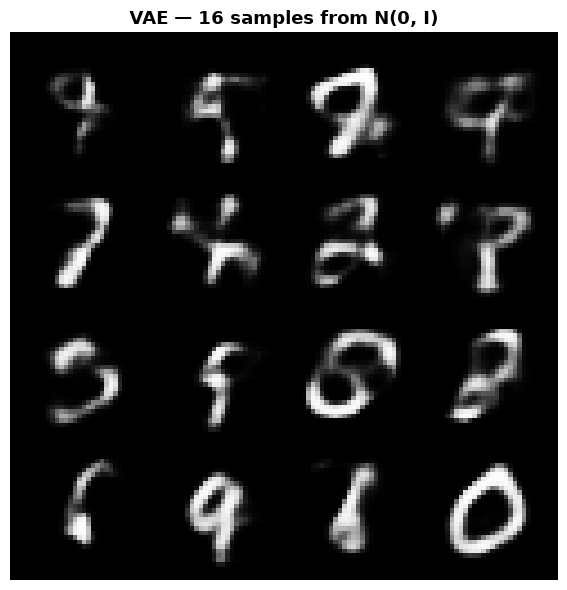

In [ ]:
vae_samples = vae_sample(vae, n_samples=16)
grid = make_grid(vae_samples, nrow=4, padding=2).permute(1, 2, 0)
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("VAE — 16 samples from N(0, I)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Exercise 2.5 — Latent-space interpolation

A trained VAE should give a *smooth* latent space: walking in a straight line between two codes should produce a smooth sequence of plausible images. Implement `vae_interpolate(model, x1, x2, n_steps=8)`:

1. Encode `x1` and `x2` with the model's `encode` method and take their **means** (`mu`) — ignore the variance.
2. Linearly interpolate between the two `mu` vectors at `n_steps` evenly spaced values of $\alpha\in[0, 1]$.
3. Decode each interpolated code, sigmoid, return as a `(n_steps, 1, 28, 28)` CPU tensor.

For input, take a `0` and a `9` from the test set.


In [ ]:
@torch.no_grad()
def vae_interpolate(
    model: VAE,
    x1: torch.Tensor,
    x2: torch.Tensor,
    n_steps: int = 8,
) -> torch.Tensor:
    device = next(model.parameters()).device
    x1 = x1.to(device)
    x2 = x2.to(device)
    mu1, _ = model.encode(x1.view(-1, model.x_dim))
    mu2, _ = model.encode(x2.view(-1, model.x_dim))
    mu1 = mu1.squeeze(0)  # Shape: (z_dim,)
    mu2 = mu2.squeeze(0)  # Shape: (z_dim,)
    alphas = torch.linspace(0.0, 1.0, steps=n_steps, device=device)
    alphas = alphas.unsqueeze(1)
    z_interp = (1.0 - alphas) * mu1 + alphas * mu2  # Shape: (n_steps, z_dim)
    logits = model.decode(z_interp)
    probs = torch.sigmoid(logits)
    return probs.view(n_steps, 1, 28, 28).cpu()

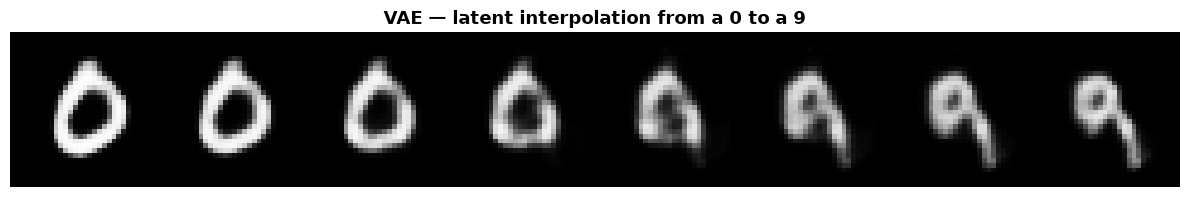

In [ ]:
# Pick a 0 and a 9 from the test set
def find_first(label: int) -> torch.Tensor:
    for img, lbl in test_set:
        if lbl == label:
            return img
    raise RuntimeError(f"No example of class {label} in test set")

x_a = find_first(0)
x_b = find_first(9)

interp = vae_interpolate(vae, x_a, x_b, n_steps=8)
grid = make_grid(interp, nrow=8, padding=2).permute(1, 2, 0)
plt.figure(figsize=(12, 2))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("VAE — latent interpolation from a 0 to a 9", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Part 3 — DDPM diffusion model (~50 min)

DDPM ([Ho et al., 2020](https://arxiv.org/abs/2006.11239)) takes a completely different angle. There is no learned encoder — the **forward (encoding) process is fixed**: gradually add Gaussian noise over $T$ steps until any image becomes pure noise. The only thing we *learn* is the **reverse** process — undoing one noising step at a time.

The forward step is

$$
q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) \;=\; \mathcal{N}\!\bigl(\sqrt{1-\beta_t}\,\mathbf{z}_{t-1},\;\beta_t\mathbf{I}\bigr),\qquad \mathbf{z}_0 \equiv \mathbf{x}.
$$

A small bit of algebra (Prince §18.3) gives the **closed-form marginal**:

$$
q(\mathbf{z}_t \mid \mathbf{x}) \;=\; \mathcal{N}\!\bigl(\sqrt{\bar\alpha_t}\,\mathbf{x},\;(1-\bar\alpha_t)\,\mathbf{I}\bigr),\qquad \bar\alpha_t = \prod_{s=1}^t (1 - \beta_s).
$$

This is the practical magic: we can sample any $\mathbf{z}_t$ from $\mathbf{x}$ in **one step**, without simulating the chain.

The training objective, after a bunch of cancellations, reduces to

$$
\mathcal{L} \;=\; \mathbb{E}_{t,\,\mathbf{x},\,\boldsymbol\varepsilon}\!\left[\bigl\|\boldsymbol\varepsilon \;-\; \mathbf{f}_{\boldsymbol\phi}\!\bigl(\sqrt{\bar\alpha_t}\,\mathbf{x} + \sqrt{1-\bar\alpha_t}\,\boldsymbol\varepsilon,\;t\bigr)\bigr\|^2\right]
$$

— a **plain MSE on noise prediction**. There is no adversary, no Jacobian, no ELBO gap to worry about. This simplicity is one of the main reasons diffusion has won.


### Exercise 3.1 — Build the noise schedule

Build the three buffers we will need throughout the rest of Part 3, on the right `device`:

- `betas = torch.linspace(1e-4, 0.02, T)` for `T = 1000`
- `alphas = 1.0 - betas`
- `alpha_bar = torch.cumprod(alphas, dim=0)`


In [ ]:
T: int = 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

### Exercise 3.2 — `q_sample`: one-shot forward noising

Implement `q_sample(x0, t, noise=None)`:

- `x0` shape `(B, 1, 28, 28)`, on `device`.
- `t` shape `(B,)` of integer timesteps in `[0, T-1]`.
- `noise` shape `(B, 1, 28, 28)` or `None` — if `None`, sample standard normal noise.
- Look up `alpha_bar[t]` and **reshape** it to `(B, 1, 1, 1)` so it broadcasts over the image axes.
- Return $\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\varepsilon$.


In [ ]:
def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    noise: torch.Tensor | None = None,
) -> torch.Tensor:
   if noise is None:
      noise = torch.randn_like(x0)
   a_bar_t = alpha_bar[t]
   a_bar_t = a_bar_t.view(-1, 1, 1, 1)
   xt = torch.sqrt(a_bar_t) * x0 + torch.sqrt(1.0 - a_bar_t) * noise
   return xt


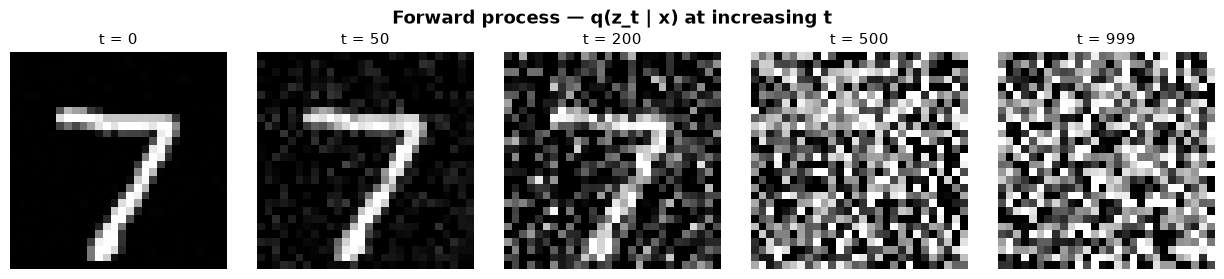

In [ ]:
# Provided visualization: one digit at increasing levels of noise
img, _ = test_set[0]                            # shape (1, 28, 28), pixels in [0, 1]
x0 = (img.to(device) * 2 - 1).unsqueeze(0)      # rescale to [-1, 1] and add batch dim
ts = [0, 50, 200, 500, 999]
noisy = []
torch.manual_seed(0)
for t_val in ts:
    t = torch.tensor([t_val], device=device)
    z_t = q_sample(x0, t)
    noisy.append(z_t.squeeze(0).cpu())

fig, axes = plt.subplots(1, len(ts), figsize=(2.5 * len(ts), 2.8))
for ax, t_val, img_t in zip(axes, ts, noisy):
    ax.imshow(((img_t.clamp(-1, 1) + 1) / 2).squeeze(), cmap="gray")
    ax.set_title(f"t = {t_val}", fontsize=11)
    ax.axis("off")
plt.suptitle("Forward process — q(z_t | x) at increasing t", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### The U-Net: backbone of the reverse process

The reverse process predicts the noise that was added to produce $\mathbf{z}_t$. Its input is an image $\mathbf{z}_t$ (shape `(B, 1, 28, 28)`) plus the timestep $t$, and its output is the same shape as the input. The standard choice is a **U-Net**:

- Encoder convs downsample the spatial dimensions.
- Decoder convs upsample back, **with skip connections from the matching encoder resolution** (same as Notebook 6).
- The timestep is injected as a **sinusoidal embedding** projected through a small MLP and added to feature maps at every block.

The `SinusoidalTimeEmb` and `ResBlock` modules below are **provided** — you do not need to modify them. Your job is to assemble them into a `SmallUNet`.


In [ ]:
class SinusoidalTimeEmb(nn.Module):
    """Standard sinusoidal positional encoding for the diffusion timestep."""

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: shape (B,) integer timesteps
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class ResBlock(nn.Module):
    """GroupNorm + SiLU conv block with timestep injection and a residual connection."""

    def __init__(self, in_c: int, out_c: int, t_emb_dim: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_c)
        self.t_proj = nn.Linear(t_emb_dim, out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_c)
        self.skip = nn.Conv2d(in_c, out_c, kernel_size=1) if in_c != out_c else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.norm1(self.conv1(x)))
        # broadcast time embedding across H, W
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


### Exercise 3.3 — `SmallUNet`

Here is a version of the U-Net using the building blocks above. The layout is as follows (with `base = 32`, `t_emb_dim = 128`):

- **Time MLP**: `SinusoidalTimeEmb(t_emb_dim) → Linear(t_emb_dim, t_emb_dim*4) → SiLU → Linear(t_emb_dim*4, t_emb_dim*4)`. Pass the result of the time MLP as `t_emb` to every `ResBlock`. (So `t_emb_dim` consumed by `ResBlock` is `t_emb_dim * 4`.)
- **Stem**: `Conv2d(1, base, 3, padding=1)`.
- **Encoder**:
  - `ResBlock(base, base, t_emb_dim*4)`, save output as skip `s1`.
  - Downsample: `nn.Conv2d(base, base, 4, stride=2, padding=1)` → 28 → 14.
  - `ResBlock(base, base*2, t_emb_dim*4)`, save output as skip `s2`.
  - Downsample: `nn.Conv2d(base*2, base*2, 4, stride=2, padding=1)` → 14 → 7.
- **Bottleneck**: `ResBlock(base*2, base*4, t_emb_dim*4)`.
- **Decoder**:
  - Upsample: `nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1)` → 7 → 14.
  - Concatenate with `s2` along the channel dim, then `ResBlock(base*4, base*2, t_emb_dim*4)`.
  - Upsample: `nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1)` → 14 → 28.
  - Concatenate with `s1`, then `ResBlock(base*2, base, t_emb_dim*4)`.
- **Head**: `Conv2d(base, 1, 3, padding=1)` — predicts the noise (same shape as input).


In [ ]:
class SmallUNet(nn.Module):
    def __init__(self, base: int = 32, t_emb_dim: int = 128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(t_emb_dim),
            nn.Linear(t_emb_dim, t_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(t_emb_dim * 4, t_emb_dim * 4),
        )
        td = t_emb_dim * 4

        # Stem
        self.stem = nn.Conv2d(1, base, kernel_size=3, padding=1)
        # Encoder
        self.enc1 = ResBlock(base, base, td)
        self.down1 = nn.Conv2d(base, base, kernel_size=4, stride=2, padding=1)
        self.enc2 = ResBlock(base, base * 2, td)
        self.down2 = nn.Conv2d(base * 2, base * 2, kernel_size=4, stride=2, padding=1)
        # Bottleneck
        self.mid = ResBlock(base * 2, base * 4, td)
        # Decoder
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=4, stride=2, padding=1)
        self.dec2 = ResBlock(base * 4, base * 2, td)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=4, stride=2, padding=1)
        self.dec1 = ResBlock(base * 2, base, td)
        # Head
        self.head = nn.Conv2d(base, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)

        h = self.stem(x)
        s1 = self.enc1(h, t_emb)
        h = self.down1(s1)
        s2 = self.enc2(h, t_emb)
        h = self.down2(s2)
        h = self.mid(h, t_emb)
        h = self.up2(h)
        h = self.dec2(torch.cat([h, s2], dim=1), t_emb)
        h = self.up1(h)
        h = self.dec1(torch.cat([h, s1], dim=1), t_emb)
        return self.head(h)


In [ ]:
# Sanity check on shapes and parameter count
unet = SmallUNet().to(device)
x_dummy = torch.randn(4, 1, 28, 28, device=device)
t_dummy = torch.randint(0, T, (4,), device=device)
out = unet(x_dummy, t_dummy)
print(f"input : {tuple(x_dummy.shape)}")
print(f"output: {tuple(out.shape)}")
n_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net parameters: {n_params:,}")


input : (4, 1, 28, 28)
output: (4, 1, 28, 28)
U-Net parameters: 1,195,265


> **Question 3.1** — Why are **skip connections** essential in a diffusion U-Net? (Hint: think about what the output has to look like, not what the bottleneck stores.)

La salida de la U-Net debe tener exactamente la misma resolución y detalle espacial fino que la entrada (predice el ruido píxel a píxel), información que el cuello de botella de baja resolución necesariamente destruye. Las skip connections reinyectan los detalles de alta frecuencia desde el encoder al decoder, permitiendo reconstruir la estructura local que el bottleneck no puede almacenar.


> **Question 3.2** — Why do we **add** the time embedding inside every residual block instead of just concatenating it once to the input image?

Sumar el embedding temporal en cada bloque residual permite que la condición de tiempo module las features en todas las profundidades y resoluciones, ya que el comportamiento óptimo de denoising cambia drásticamente entre $t$ alto y bajo. Concatenarlo solo una vez a la entrada haría que la señal temporal se diluyera y se perdiera a medida que avanza por la red.



### Exercise 3.4 — The training objective

Implement `diffusion_loss(model, x0, T)`:

1. Rescale `x0` from `[0, 1]` to `[-1, 1]` (standard DDPM practice — gives zero mean).
2. Sample timesteps `t ~ U{0, T-1}` of shape `(B,)`.
3. Sample noise `eps ~ N(0, I)` of shape `(B, 1, 28, 28)`.
4. Compute `z_t = q_sample(x0_rescaled, t, noise=eps)`.
5. Run the model: `eps_hat = model(z_t, t)`.
6. Return `F.mse_loss(eps_hat, eps)`.


In [ ]:
def diffusion_loss(model: nn.Module, x0: torch.Tensor, T: int) -> torch.Tensor:
    B = x0.size(0)
    device = x0.device
    x0_rescaled = 2.0 * x0 - 1.0
    t = torch.randint(0, T, (B,), device=device)
    eps = torch.randn_like(x0_rescaled)
    z_t = q_sample(x0_rescaled, t, noise=eps)
    eps_hat = model(z_t, t)
    return F.mse_loss(eps_hat, eps)

### Exercise 3.5 — Train the DDPM

Train the U-Net. Suggested: `ddpm_epochs = 20`, `lr = 2e-4`, `AdamW`. Record the loss per epoch.


In [ ]:
import torch
import torch.optim as optim
from tqdm.auto import tqdm
device = torch.device("mps") if torch.backends.mps.is_available() else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
ddpm_epochs = 20
lr = 2e-4
T = 1000
model = SmallUNet().to(device)
optimizer = optim.AdamW(model.parameters(), lr=lr)
ddpm_losses = []
for epoch in range(ddpm_epochs):
    model.train()
    running_loss = 0.0
    total_samples = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{ddpm_epochs:02d}", leave=False)

    for x, _ in pbar:
        x = x.to(device)
        batch_size = x.size(0)
        optimizer.zero_grad()
        loss = diffusion_loss(model, x, T=T)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_size
        total_samples += batch_size
        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})
    epoch_loss = running_loss / total_samples
    ddpm_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:02d}/{ddpm_epochs:02d} completed | Average Training Loss: {epoch_loss:.5f}")
unet = model


Epoch 01/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 01/20 completed | Average Training Loss: 0.11313


Epoch 02/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 02/20 completed | Average Training Loss: 0.04715


Epoch 03/20:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 18/20 completed | Average Training Loss: 0.02535


Epoch 19/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19/20 completed | Average Training Loss: 0.02515


Epoch 20/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 20/20 completed | Average Training Loss: 0.02497


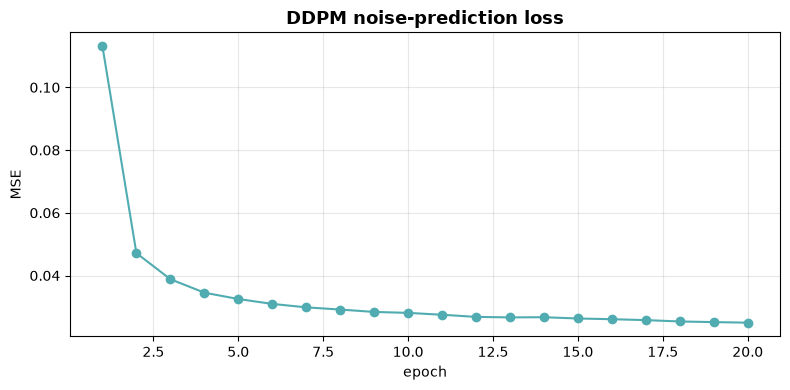

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, ddpm_epochs + 1), ddpm_losses, color=C2, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("DDPM noise-prediction loss", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Exercise 3.6 — DDPM reverse sampling

The DDPM reverse step (Ho et al. 2020, equation (11)) is

$$
\mathbf{z}_{t-1} \;=\; \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{z}_t \;-\; \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol\varepsilon_{\boldsymbol\phi}(\mathbf{z}_t, t)\right) \;+\; \sigma_t\,\boldsymbol\xi,
$$

with $\sigma_t^2 = \beta_t$ and $\boldsymbol\xi\sim\mathcal{N}(0,\mathbf{I})$ for $t > 0$, and no noise added at the final step ($t = 0$).

Implement `ddpm_sample(model, n_samples, T)`:

1. Start `z = torch.randn(n_samples, 1, 28, 28, device=device)`.
2. For `t` from `T-1` down to `0`:
   - Build `t_batch = torch.full((n_samples,), t, ...)`.
   - Predict noise `eps_hat = model(z, t_batch)`.
   - Compute the mean update.
   - If `t > 0`, add `sqrt(beta_t) * noise` where `noise ~ N(0, I)`.
3. After the loop, rescale `z` from `[-1, 1]` back to `[0, 1]` and clamp.
4. Return as a CPU tensor.

Wrap the body in `@torch.no_grad()`.


In [ ]:
@torch.no_grad()
def ddpm_sample(
    model: nn.Module,
    n_samples: int,
    T: int,
    track_every: int | None = None,
) -> tuple[torch.Tensor, list[torch.Tensor]]:
    device = next(model.parameters()).device
    z = torch.randn(n_samples, 1, 28, 28, device=device)
    trajectory_list = []
    def get_tracked_frame(tensor):
        frame = (tensor + 1.0) / 2.0
        return torch.clamp(frame, 0.0, 1.0).cpu()
    for t in reversed(range(T)):
        t_batch = torch.fill(torch.empty(n_samples, dtype=torch.long, device=device), t)
        eps_hat = model(z, t_batch)
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bar[t]
        coeff1 = 1.0 / torch.sqrt(alpha_t)
        coeff2 = beta_t / torch.sqrt(1.0 - alpha_bar_t)
        z_mean = coeff1 * (z - coeff2 * eps_hat)
        if t > 0:
            noise = torch.randn_like(z)
            z = z_mean + torch.sqrt(beta_t) * noise
        else:
            z = z_mean
        if track_every is not None and (T - 1 - t) % track_every == 0:
            trajectory_list.append(get_tracked_frame(z))
    final_samples = get_tracked_frame(z)
    if track_every is not None and len(trajectory_list) == 0 or (track_every is not None and (T - 1) % track_every != 0):
        trajectory_list.append(final_samples)
    return final_samples, trajectory_list

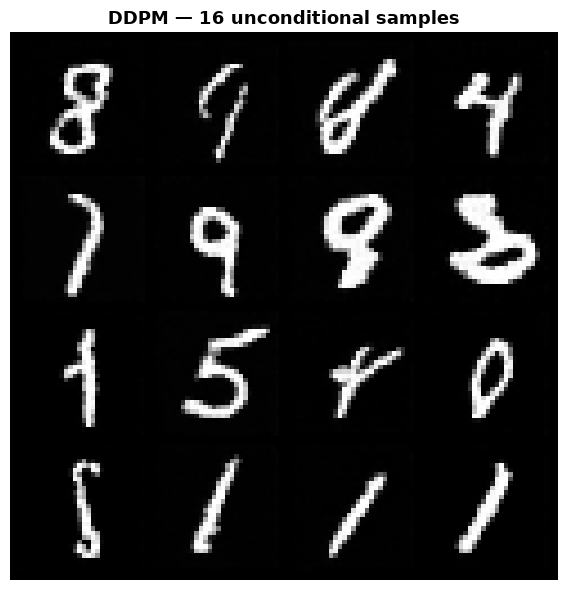

In [ ]:
ddpm_samples, _ = ddpm_sample(unet, n_samples=16, T=T)
grid = make_grid(ddpm_samples, nrow=4, padding=2).permute(1, 2, 0)
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("DDPM — 16 unconditional samples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


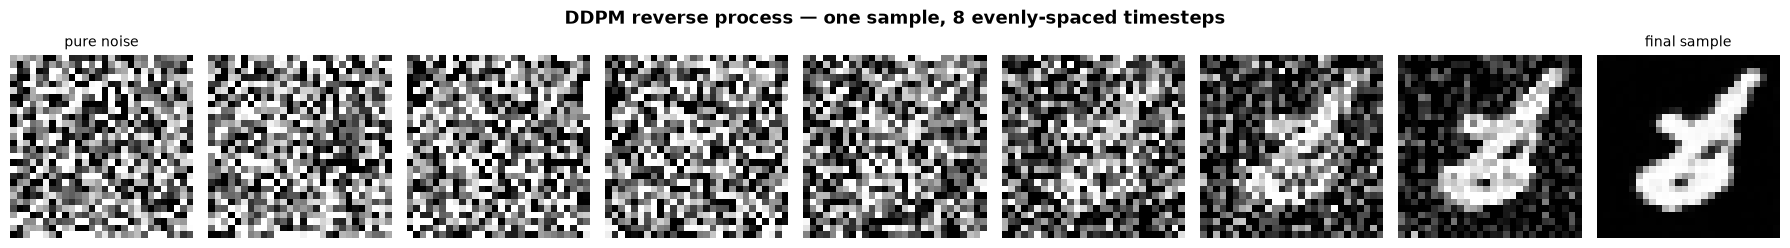

In [ ]:
# Provided: visualize the reverse process for a single sample
torch.manual_seed(7)
_, traj = ddpm_sample(unet, n_samples=1, T=T, track_every=T // 8)
# `traj` is collected from t = T-1 down to t = 0 — show in that order
fig, axes = plt.subplots(1, len(traj), figsize=(2 * len(traj), 2.5))
for ax, img_t in zip(axes, traj):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
axes[0].set_title("pure noise", fontsize=10)
axes[-1].set_title("final sample", fontsize=10)
plt.suptitle("DDPM reverse process — one sample, 8 evenly-spaced timesteps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


> **Question 3.3** — Sampling 16 images cost you 16 × `T` = **16,000** U-Net forward passes. Compare this with the VAE — how many forward passes did `vae_sample(model, n_samples=16)` cost? What does this say about which model you would deploy in a real-time system?

El VAE costó solo 16 forward passes (uno por muestra), frente a los 16.000 del DDPM, una diferencia de tres órdenes de magnitud. Esto implica que en un sistema de tiempo real elegirías el VAE (o un sampler acelerado como DDIM), porque el muestreo iterativo del DDPM es prohibitivamente lento.


---

## Part 4 — Side-by-side comparison (~10 min)


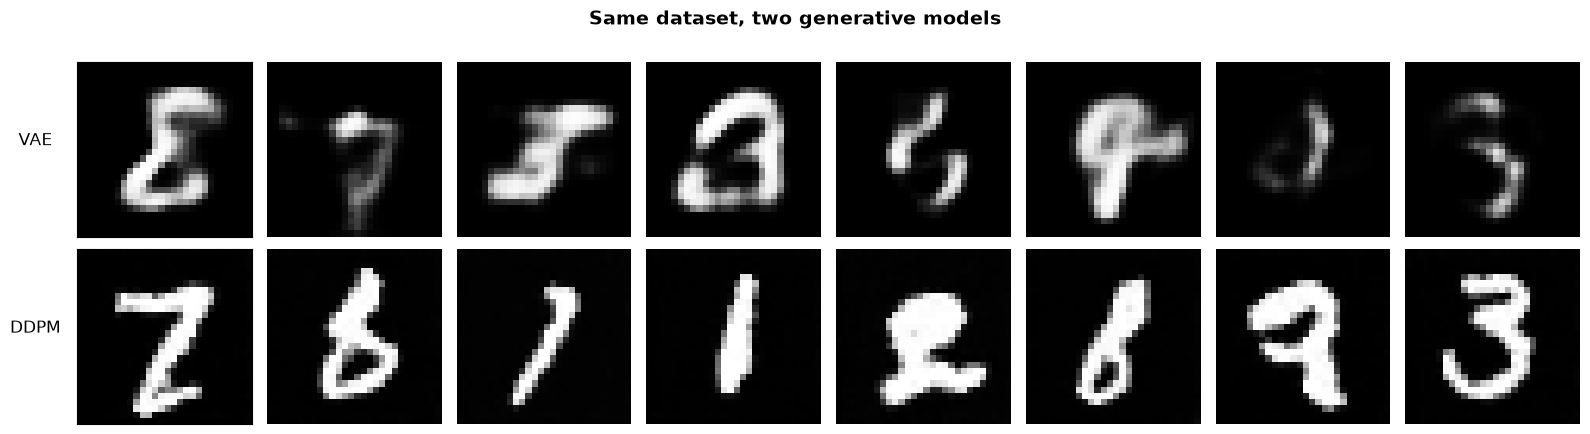

In [ ]:
vae_compare = vae_sample(vae, n_samples=8)
ddpm_compare, _ = ddpm_sample(unet, n_samples=8, T=T)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, img_t in zip(axes[0], vae_compare):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
for ax, img_t in zip(axes[1], ddpm_compare):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
axes[0, 0].set_ylabel("VAE",  fontsize=12, rotation=0, labelpad=30); axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[1, 0].set_ylabel("DDPM", fontsize=12, rotation=0, labelpad=30); axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
plt.suptitle("Same dataset, two generative models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


> **Question 4.1** — Describe **one visible failure mode of the VAE** and **one visible failure mode of the DDPM** in your samples.

El VAE muestra dígitos borrosos y "promediados", a veces ambiguos entre dos clases por la difuminación del decoder gaussiano/Bernoulli. El DDPM produce dígitos nítidos pero ocasionalmente genera formas deformes o que no corresponden a ningún dígito válido, fruto de errores acumulados en la cadena de denoising.


> **Question 4.2** — Map each model onto the (likelihood, sample quality, sampling speed) triangle from lecture §6. For each of the following deployments, which model would you pick and why?
>
> - (a) Anomaly detection on factory-floor camera images.
> - (b) Generating a high-resolution marketing avatar.
> - (c) Compressing handwritten digits into a 16-dimensional code for a downstream classifier.


El VAE tiene buena verosimilitud y latente útil pero baja calidad de muestra y muestreo rapidísimo; el DDPM tiene alta calidad de muestra pero muestreo lentísimo y sin código latente. Las elecciones serían:

- **(a) Detección de anomalías:** VAE, por su latente y verosimilitud útiles para detectar anomalías como reconstrucciones de baja probabilidad.
- **(b) Avatar de marketing en alta resolución:** DDPM, porque prioriza calidad y nitidez visual.
- **(c) Compresión a código de 16 dimensiones:** VAE, ya que es el único que provee directamente el código comprimido latente.



---

## Part 5 — Optional: HuggingFace `diffusers` with a tiny pretrained model (~25 min)

We just built a 28×28 MNIST diffusion model. Production diffusion models share the *same math* (β schedule, U-Net, noise prediction) but are pretrained on millions of images at much higher resolution, with conditional inputs (text, class), classifier-free guidance, and faster samplers.

[`diffusers`](https://huggingface.co/docs/diffusers/index) is HuggingFace's library for these models. It packages everything — the U-Net, the scheduler (DDPM, DDIM, …), the conditional inputs — into a `Pipeline` object with a single `__call__` API. We use a **tiny pretrained model** (`google/ddpm-cifar10-32`, 32×32 CIFAR-10) so the download is small and inference works on any hardware (CPU is slow but feasible; MPS/CUDA is comfortable). Stable Diffusion would teach the same lesson but needs ~6 GB of VRAM and a much larger download.


In [ ]:
try:
    from diffusers import DDPMPipeline, DDIMScheduler  # noqa: F401
except ImportError:
    %pip install -q diffusers accelerate
    from diffusers import DDPMPipeline, DDIMScheduler


### Exercise O.1 — Pretrained DDPM pipeline

Load `google/ddpm-cifar10-32`, move it to `device`, and sample 4 images with the default DDPM scheduler (1000 inference steps). Time the call. Display the four samples in a row.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/valentin.rodriguez.machado/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/valentin.rodriguez.machado/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

DDPM (1000 steps): 20.2s


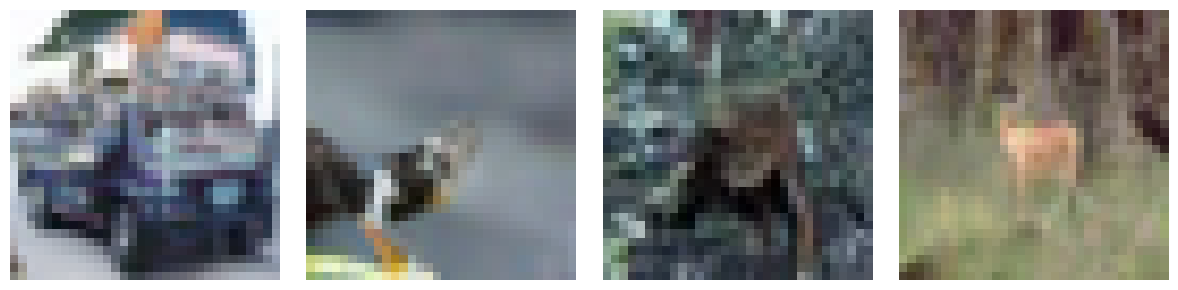

In [ ]:

# YOUR CODE HERE — load `google/ddpm-cifar10-32`, sample 4 images with the default
# DDPM scheduler (num_inference_steps=1000), time the call, display the samples.
import time
import torch
import matplotlib.pyplot as plt

pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)

# MPS: generator must be on CPU (diffusers randn_tensor workaround)
gen_device = 'cpu' if device.type == 'mps' else device
generator = torch.Generator(device=gen_device).manual_seed(0)
t0 = time.time()
out = pipe(batch_size=4, num_inference_steps=1000, generator=generator)
print(f"DDPM (1000 steps): {time.time() - t0:.1f}s")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img in zip(axes, out.images):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.savefig('/tmp/ddpm_pretrained_samples.png', dpi=100)
plt.show()

### Exercise O.2 — Swap the scheduler to DDIM

`diffusers` lets you swap the **scheduler** without retraining the U-Net. **DDIM** reformulates the reverse process as a deterministic ODE that can be solved in many fewer steps.

Swap `pipe.scheduler` to a DDIM scheduler built from the same config, re-sample 4 images with `num_inference_steps=50`, time it, and display. (The U-Net weights are unchanged — only the integration scheme.)


  0%|          | 0/50 [00:00<?, ?it/s]

DDIM (50 steps): 1.0s


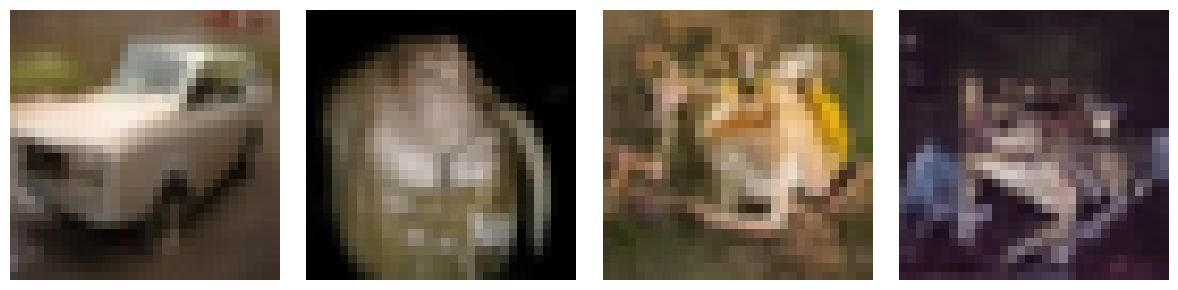

In [ ]:
# YOUR CODE HERE — swap pipe.scheduler to a DDIM scheduler from the same config,
# re-sample with num_inference_steps=50, time it, display.
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

gen_device = 'cpu' if device.type == 'mps' else device
generator = torch.Generator(device=gen_device).manual_seed(0)
t0 = time.time()
out = pipe(batch_size=4, num_inference_steps=50, generator=generator)
print(f"DDIM (50 steps): {time.time() - t0:.1f}s")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img in zip(axes, out.images):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()


> **Question O.1** — Did the DDIM samples look meaningfully worse with **20× fewer steps**? Connect this to the ODE / deterministic-reformulation note in lecture §5.3.

No, las muestras de DDIM se ven prácticamente igual de buenas con 20× menos pasos, gracias a que reformula el proceso inverso como una ODE determinista que puede integrarse con pasos mucho más grandes sin acumular ruido estocástico. Esto confirma la nota de la §5.3: al eliminar la aleatoriedad y resolver la trayectoria como ODE, se logra el mismo destino con muchas menos evaluaciones.

> **Question O.2** — If you wanted to fine-tune `pipe.unet` on, say, 1000 custom logos at 32×32, what would you change in the pipeline you just used? (No code — just describe.)

Mantendrías la misma arquitectura de `pipe.unet` y el scheduler, pero cargarías los pesos preentrenados como punto de partida y los seguirías entrenando con el objetivo de predicción de ruido sobre tu dataset de 1000 logos. Lo clave sería usar un learning rate bajo, pocos epochs y data augmentation para no sobreajustar a un dataset tan chico, además de ajustar la resolución/normalización al formato de los logos.


---

## Done!

You've built two complete generative models from scratch on the same dataset and seen — visually — the trade-off the lecture spent a whole table on. A few things worth noting before you close the notebook:

- The **VAE** was light, stable, gave you a meaningful 16-d code, and produced blurry but recognisable digits.
- The **DDPM** was heavier to train and *much* slower to sample, but the samples are crisp and there is no encoder–decoder gap.
- The optional `diffusers` section gave you a feel for the production toolchain: the same math, packaged so that swapping the sampler from DDPM to DDIM is a one-line change.
- The other two families from the lecture — **GANs** and **normalizing flows** — are conceptually similar exercises if you want to keep going on your own.

Next lecture moves from generation to **reinforcement learning**, where the data distribution is shaped by the agent's own actions — a closing topic that ties together perception, modelling, and decision-making.
